In [11]:
<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

SyntaxError: invalid syntax (3115804443.py, line 1)

> This notebook is created based on the notes from 
> - **Main Notes 2026/01** (Francisco Förster Burón):  
>   - https://github.com/fforster/AS4501/tree/main
> - Valetino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> Paula Caceres, Javiera Toro, Melissa FuenteAlba, ..

# Aux 2: Bayesian Estimation

## Bayes' Theorem 

This theorem describes a method to update probabilities based on data and past knowledge.

$\textbf{X}$: Observed data.

$\hat\theta$: Parameter vector.

$\textbf{M}$: Model.

$$ \large P(\hat\theta|X,M) = \frac{P(X|\hat\theta,M) P(\hat\theta|M)}{P(X|M)} $$

$\bigstar$ $P(X|\hat\theta,M)$ is the likelihood function, it describes the joint probability of the observed data as a function of the parameters of the chosen statistical model.

$\bigstar$  $P(\hat\theta|M)$ is the prior, an initial probability distribution that is assigned to the parameters, without further evidence.

$\bigstar$  $P(X|M)$ is the marginalized distribution of the dataset over all parameter values in model M, also called marginal likelihood or model evidence BUT this parameter can be very hard to compute in many cases. For this reason, we disregard it and uses as a normalization factor.

$\bigstar$  $P(\hat\theta|X,M)$ is the posterior distribution (what we want).

# Bayesian Parameter Estimation

Let's consider the visibilites of the HD 143006 protoplanetary disk, observed with the Atacama Large Millimeter/submillimeter Array. Let's use Bayesian statistics to learn about the intrinsic parameters of the distribution.

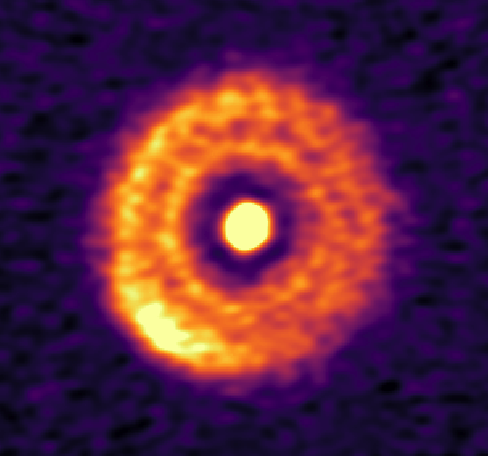 \
Fig: A snapshot of HD143006 in the image plane.

In interferometry (in particular with ALMA), we measure the Fourier transform of the sky’s brightness distribution. \
In the case of HD 143006, this disk exhibits various substructures (such as an inner cavity, a ring, and an asymmetric bright arc). \
For this example, we will only focus on the ring that encloses the inner cavity. \
If we assume an infinitely thin ring of radius $R$ with total flux $F_0$, its visibility profile (real amplitude) as a function of the distance $uv$ ($\rho$) is a Bessel function of the first kind of order zero ($J_0$):$$V(\rho) = F_0 J_0(2\pi \rho R)$$Since real rings have a spatial width, we convolve the ring with a Gaussian kernel of width $\sigma$. In Fourier space, this is equivalent to multiplying by a Gaussian distribution:$$V(\rho) = F_0 J_0(2\pi \rho R) \exp(-2\pi^2 \sigma^2 \rho^2)$$(Note: $\rho$ is expressed in multiples of the observation wavelength ($\lambda$), and $R$ and $\sigma$ must be in radians for the argument to be dimensionless).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

(0.0, 5519830.717110674)

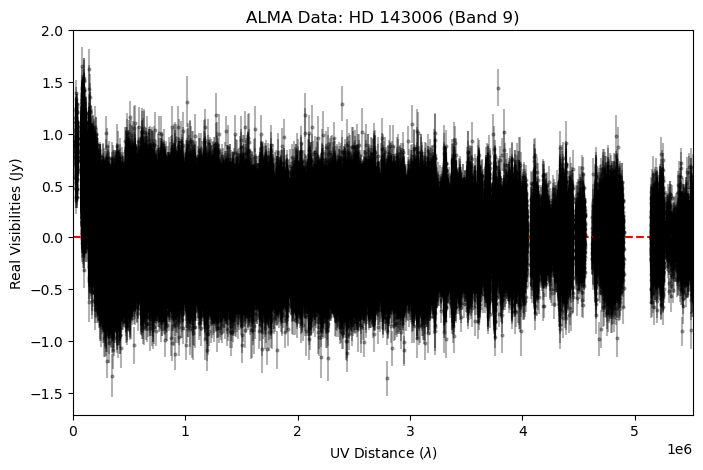

In [2]:
# Upload the data extracted from ALMA
df = pd.read_csv('hd143006_emcee_data.csv')
uv_dist = df['uv_dist'].values
V_real = df['v_real'].values
V_err = df['v_err'].values

# View the data for HD 143006 in the UV plane
plt.figure(figsize=(8, 5))
plt.errorbar(uv_dist, V_real, yerr=V_err, fmt='o', markersize=2, alpha=0.3, color='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel(r'UV Distance ($\lambda$)')
plt.ylabel('Real Visibilities (Jy)')
plt.title('ALMA Data: HD 143006 (Band 9)')
plt.xlim(0, max(uv_dist))

In [3]:
from scipy.special import j0

def model_ring(uv_dist, F_tot, R_arcsec, sigma_arcsec):
    """
    Calculate the 1D visibility profile for a Gaussian ring.
    uv_dist: UV distance in wavelengths (lambda).
    """
    # Convert from arcseconds to radians
    R_rad = R_arcsec / 206265.0
    sigma_rad = sigma_arcsec / 206265.0
    
    # Ring term (Bessel)
    bessel_term = j0(2 * np.pi * uv_dist * R_rad)
    
    # Gaussian term (Gaussian Decay)
    gauss_term = np.exp(-2 * np.pi**2 * sigma_rad**2 * uv_dist**2)
    
    return F_tot * bessel_term * gauss_term

## General steps for a Bayesian Analysis

1. Define your priors
1. Specify how to calculate the likelihood
1. Now you can build your posterior and interrogate it
    - If your posterior can be treated analytically, you can just plot it, ask about the its maximum, confidence intervals, etc.
    - If it's not easily treated analytically, then you can draw a random sample from it using, for example, MCMC methods and ask the same questions based on the random sample.

### 1. Define the prior

Assuming that we know nothing about this sample (this is not always the case), we need to give as little info as possible. The goal is to define a function that when evaluated we get the probability density associated to the parameter values.

We will use `emcee` in this example, so we actually need to define a function that returns log of the prior.

In [4]:
def log_prior(params):
    F_tot, R_arcsec, sigma_arcsec = params
    # We set reasonable physical limits
    # The flux must be positive, we will choose the radius between 0 and 2 arcseconds, and the width positive.
    if 0.0 < F_tot < 5.0 and 0.0 < R_arcsec < 2.0 and 0.0 < sigma_arcsec < 1.0:
        return 0.0
    return -np.inf

### 2. Specify how to calculate the likelihood

This is the crucial part, we need to be able to estimate the probability density associated to obtaining a given datum, given a set of parameters.

Again, because we are using `emcee`, we need to create a function that returns the log of the likelihood.

In [5]:
def log_likelihood(params, uv_dist, V_real, V_err):
    F_tot, R_arcsec, sigma_arcsec = params
    
    # We use the model previusly described using the parameters proposed
    model = model_ring(uv_dist, F_tot, R_arcsec, sigma_arcsec)
    
    # We calculate the log-likelihood assuming Gaussian and independent errors
    # We compare the real part of the data’s visibility with that of the model
    chi2 = np.sum(((V_real - model) / V_err)**2)
    
    return -0.5 * chi2

### 3. Build and Interrogate the Posterior

In [6]:
def log_posterior(params, uv_dist, V_real, V_err):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, uv_dist, V_real, V_err)

We will interrogate the posterior through an random sample so, let's create the sample

### Now run the MCMC to create a random sample

In [7]:
import emcee
import tqdm # just for look the progress of MCMC

ndim = 3 # [F_tot, R_arcsec, sigma_arcsec]
nwalkers = 32

# Approximate initial values
F_guess = 0.5
R_guess = 0.4
sigma_guess = 0.1

# We initialise the walkers in a small Gaussian ball around our estimate
pos = [np.array([F_guess, R_guess, sigma_guess]) + 1e-4 * np.random.randn(ndim) for i in range(nwalkers)]

# We configure the sampler by feeding it our data (uv_dist, V_real, V_err)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(uv_dist, V_real, V_err))

# Let's running the chain
sampler.run_mcmc(pos, 1000, progress=True);

100%|███████████████████████████████████████| 1000/1000 [06:07<00:00,  2.72it/s]


### Now you can start inspecting and interrogating the random sample.

Before analysing the results, we must bear in mind that the ‘walkers’ started from random positions and took some time to converge towards the area of maximum probability. This initial phase is known as the burn-in period, and we must discard it so that it does not skew our final results. We will also ‘flatten’ the chain to produce a single, large list of samples.

In [8]:
# We discard the first 300 steps (burn-in)
# 'flat=True' flattens the matrix of (nwalkers, nsteps, ndim) into a single list of (nwalkers*nsteps, ndim)
valid_samples = sampler.get_chain(discard=300, thin=15, flat=True)

print(f"We have a total of {len(valid_samples)} valid samples for estimating the parameters.")

We have a total of 1472 valid samples for estimating the parameters.


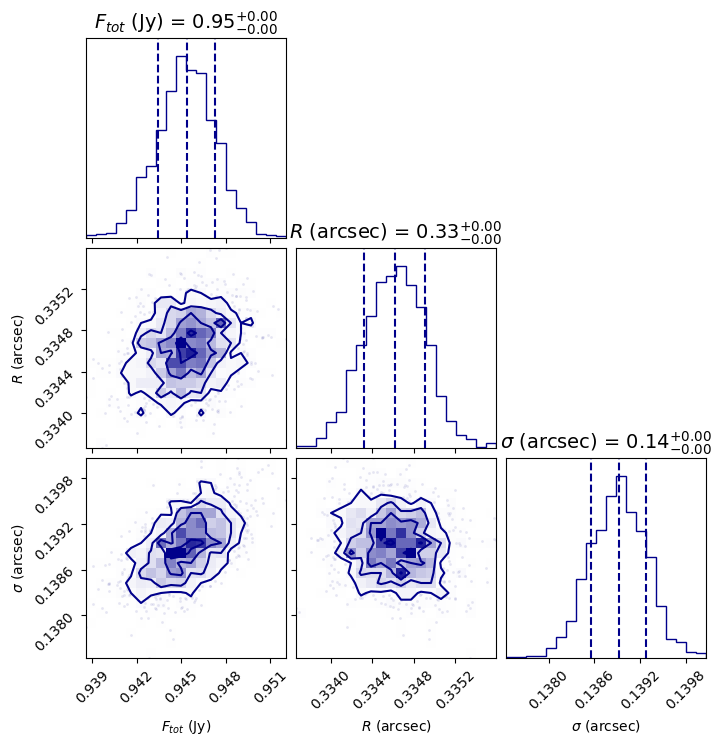

In [9]:
import corner

# We define the names of our parameters for the axes
params_names = [r"$F_{tot}$ (Jy)", r"$R$ (arcsec)", r"$\sigma$ (arcsec)"]

# We generate the corner plot
fig = corner.corner(
    valid_samples, 
    labels=params_names,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,            
    title_kwargs={"fontsize": 14},
    color='darkblue'
)

# Comparation in the image plane

There is a snapshot of the semi-axes values calculated from a ellipse fitted to the ring. So we can get an idea of how good was the estimation infered with our Bayesian analysis.

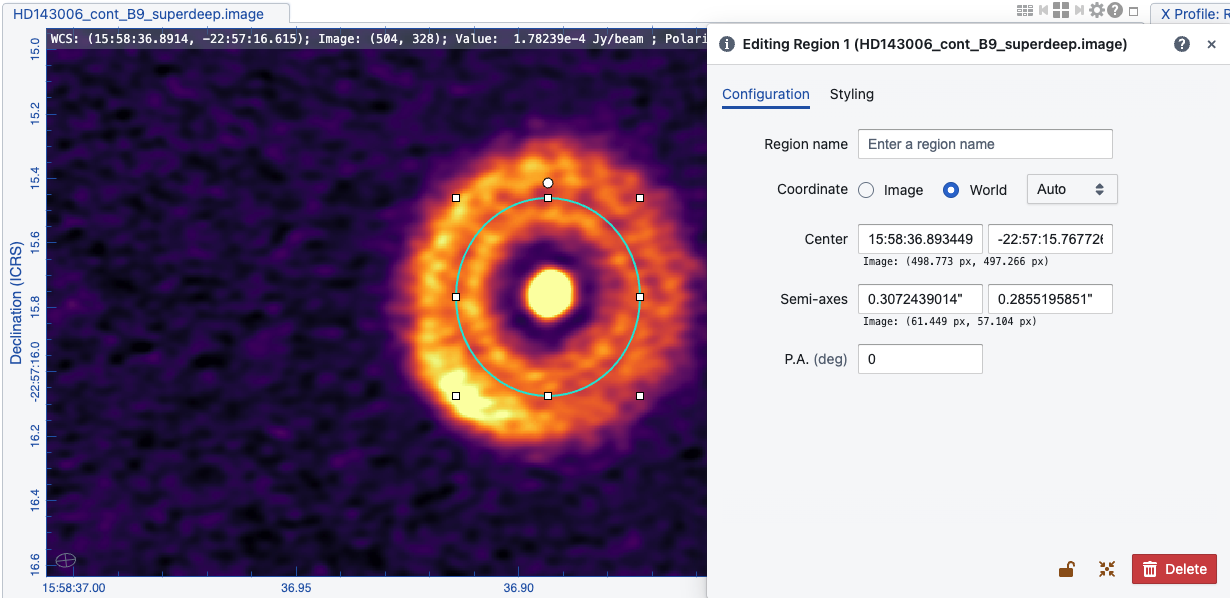